In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Определение погрешности грузов

In [2]:
m_data = pd.read_csv(
    "data/m1321.csv",
    sep=r";",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)

In [3]:
m_data["d_m"] = np.abs(m_data["m_изм"] - m_data["m_ук"])
m_data

,m_ук,m_изм,d_m
0,100,100.2,0.2
1,100,100.5,0.5
2,100,100.3,0.3
3,100,100.4,0.4
4,50,49.3,0.7
5,50,49.4,0.6
6,50,49.2,0.8
7,50,49.3,0.7
8,50,49.3,0.7
9,50,50.6,0.6


Заметно, что d_m лучше принять равным 1 г.

In [4]:
d_m = 1 # г

# Определение диаметров проволоки, внешнего и внутреннего диаметров шкива

In [5]:
d_data = pd.read_csv(
    "data/d1321.csv",
    sep=r";",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)
d = d_data["d_мк"].mean() # мм
d_d_stat = np.std(d_data["d_мк"], ddof=1) / np.sqrt(d_data["d_мк"].size) # мм
d_d_inst = 0.01 # мм
d_d = np.sqrt(d_d_stat ** 2 + d_d_inst ** 2)

R = d / 2 # мм
d_R = d_d / 2 # мм
print(R, d_R)

2.4387499999999998 0.00523978598254328


In [6]:
block_data = pd.read_csv(
    "data/block1321.csv",
    sep=r";",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)
D_ext = block_data["D"].mean() # см
d_D_ext_stat = np.std(block_data["D"], ddof=1) / np.sqrt(block_data["D"].size) # см
d_D_ext_inst = 0.005 # см
d_D_ext = np.sqrt(d_D_ext_stat ** 2 + d_D_ext_inst ** 2)

delta_D = block_data["d_D_вн"].mean() # см
d_delta_D_stat = np.std(block_data["d_D_вн"], ddof=1) / np.sqrt(block_data["d_D_вн"].size) # см
d_delta_D_inst = 0.005 # см
d_delta_D = np.sqrt(d_delta_D_stat ** 2 + d_delta_D_inst ** 2)

D_int = D_ext - delta_D
d_D_int = d_D_ext + d_delta_D

R_int = D_int / 2 # см
d_R_int = d_D_int / 2 # см
print(R_int, d_R_int)

5.198125000000001 0.006504093770532746


In [7]:
g = 9.81 # Н/кг
d_g = 0.01

L = 139 # см
d_L = 1 # см

d_n = 1 # мм

l = 132.8 # см
d_l = 0.1 # см

# Обработка данных

In [8]:
data = pd.read_csv(
    "data/data1321.csv",
    sep=r";",      # разделитель — пробелы/табы
    decimal=",",     # запятая как десятичный разделитель
    skiprows=[1],    # пропустить строку с единицами "мм мм"
    encoding="utf-8"
)

In [9]:
data["d_m"] = d_m * data["N"]
data["M"] = 2 * data["m"] / 1000 * g * R_int / 100 * 10 # Н*м * 10 ** -1
data["eps_M"] = data["d_m"] / data["m"] + d_g / g + d_R_int / R_int
data["d_M"] = data["eps_M"] * data["M"] # Н*м * 10 ** -1

data["phi"] = data["n"] / (L * 10)
data["eps_phi"] = d_n / data["n"] + d_L / L
data.iloc[0, 8] = 0.01
data["d_phi"] = data["eps_phi"] * data["phi"]

data["phi_gradus"] = data["phi"] * 180 / np.pi
data["d_phi_gradus"] = data["eps_phi"] * data["phi_gradus"]

#data[["M", "d_M", "phi_gradus", "d_phi_gradus", "phi", "d_phi"]]
data["eps_f"] = data["eps_M"] + data["eps_phi"]
data

,m,n,N,d_m,M,eps_M,d_M,phi,eps_phi,d_phi,phi_gradus,d_phi_gradus,eps_f
0,50,0,1,1,0.509936,0.022271,0.011357,0.000000,0.010000,0.000000,0.000000,0.000000,0.032271
1,100,21,2,2,1.019872,0.022271,0.022713,0.015108,0.054813,0.000828,0.865620,0.047447,0.077084
2,150,42,3,3,1.529808,0.022271,0.034070,0.030216,0.031004,0.000937,1.731239,0.053675,0.053274
3,200,59,4,4,2.039744,0.022271,0.045426,0.042446,0.024143,0.001025,2.431979,0.058716,0.046414
4,250,83,5,5,2.549680,0.022271,0.056783,0.059712,0.019242,0.001149,3.421259,0.065833,0.041513
5,300,102,6,6,3.059616,0.022271,0.068140,0.073381,0.016998,0.001247,4.204438,0.071468,0.039269
6,300,104,4,4,3.059616,0.015604,0.047742,0.074820,0.016810,0.001258,4.286878,0.072061,0.032414
7,350,123,5,5,3.569552,0.016556,0.059099,0.088489,0.015324,0.001356,5.070058,0.077695,0.031881
8,400,144,6,6,4.079489,0.017271,0.070455,0.103597,0.014139,0.001465,5.935678,0.083923,0.031409
9,450,164,7,7,4.589425,0.017826,0.081812,0.117986,0.013292,0.001568,6.760078,0.089854,0.031118


$M = f \phi$

In [10]:
def least_squares_line(x, y): # y = kx + b
    k = (np.mean(x*y) - np.mean(x) * np.mean(y)) / (np.mean(x*x) - (np.mean(x) ** 2))
    d_k = 1 / np.sqrt(len(x) - 1) * np.sqrt(((y*y).mean() - (y.mean() ** 2)) / ((x*x).mean() - (x.mean() ** 2)) - k ** 2)
    b = np.mean(y) - k * np.mean(x)
    d_b = d_k * np.sqrt(np.mean(x*x) - (np.mean(x) ** 2))
    return k, d_k, b, d_b

f, d_f_stat, b, d_b = least_squares_line(data["phi"], data["M"]) # Н*м * 10 ** -1 / рад
f = f / 10 # Н * м / рад
d_f_stat = d_f_stat / 10 # Н * м / рад
d_f_inst = f * data["eps_f"].mean()
d_f = np.sqrt(d_f_stat ** 2 + d_f_inst ** 2)
print(f, d_f)

3.500026581214615 0.14314816591382268


In [11]:
G = 2 * f * (l / 100) / (np.pi * ((R / 1000) ** 4)) / 1000 / 1000 / 1000 # ГПа
eps_G = d_f / f + d_l / l + 4 * d_R / R
d_G = G * eps_G
print(G, d_G)

83.65278631017745 4.203250799079592


# Построение графика

In [12]:
mf_g, d_mf_g, mb_g, d_mb_g = least_squares_line(data["M"], data["phi_gradus"])
xline = np.linspace(0, 6, 10)
yline = xline * mf_g + mb_g

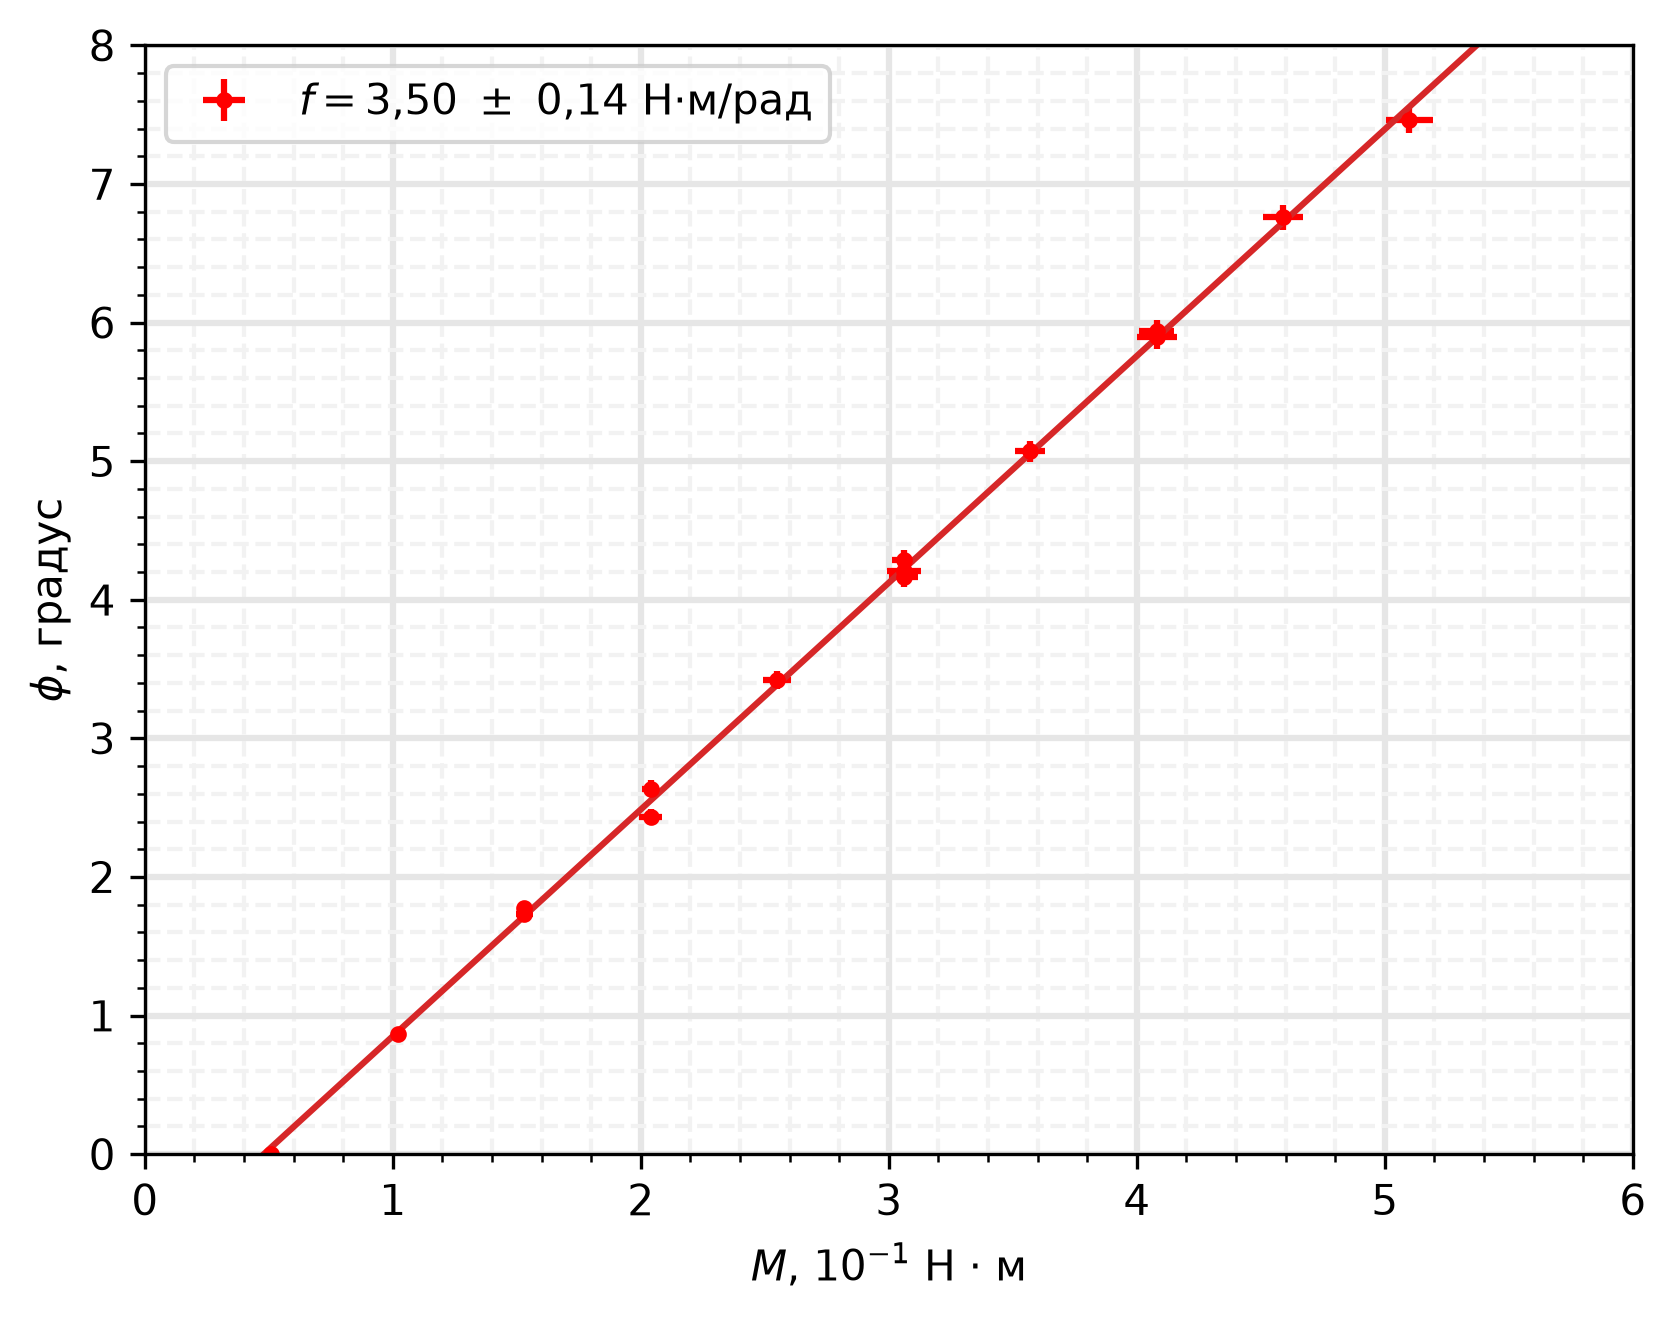

In [13]:
plt.figure(dpi=300)
plt.axis([0, 6, 0, 8])
plt.minorticks_on()
plt.xlabel("$M$, $10^{-1}$ Н $\\cdot$ м")
plt.ylabel("$\\phi$, градус")

plt.grid(visible=True, which='major', linestyle='-', linewidth=1.5, color='0.9') # Формат основных линиий сетки
plt.grid(visible=True, which='minor', linestyle='--', linewidth=1, color='0.95') # Формат побочных линий, цвет указывается как оттенок серого - 0.0 - чёрный, 1.0 - белый

plt.errorbar(data["M"], data["phi_gradus"], xerr=data["d_M"], yerr=data["d_phi_gradus"], fmt="ro", markersize=3, label="$f=3{,}50\\ \\pm\\ 0{,}14$ Н$\\cdot$м/рад")
plt.plot(xline, yline, color="tab:red")

plt.legend()
plt.savefig("images/graph1321.pdf", format="pdf")